# Side View Only Volume Estimation
# Frozen Feature Extractor + Regression Head

This notebook trains and evaluates different combinations of frozen feature extractors and regression heads on the ONLY the side view data.


In [1]:
import datetime
import warnings
from IPython.display import display
from sklearn.model_selection import ParameterGrid
from src.helpers import *
from src.frozen_pipeline import *
from src.training_and_evaluation import *
from src.constants import *

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)

## Load Data


In [2]:
samples, image_paths = load_image_paths(CSV_PATH, TOP_FOLDER, SIDE_FOLDER)
print("Samples shape:", samples.shape)
display(samples[["exp_id", "volume", "top_path", "side_path"]].head(8))

Samples shape: (423, 24)


,exp_id,volume,top_path,side_path
0,1,1.06,photos/top_view_images/P2260331.JPG,photos/side_view_images/P2260685.JPG
1,1,2.12,photos/top_view_images/P2260332.JPG,photos/side_view_images/P2260686.JPG
2,1,3.18,photos/top_view_images/P2260333.JPG,photos/side_view_images/P2260687.JPG
3,1,4.24,photos/top_view_images/P2260334.JPG,photos/side_view_images/P2260688.JPG
4,2,1.06,photos/top_view_images/P2260335.JPG,photos/side_view_images/P2260689.JPG
5,2,2.12,photos/top_view_images/P2260336.JPG,photos/side_view_images/P2260690.JPG
6,2,3.18,photos/top_view_images/P2260337.JPG,photos/side_view_images/P2260692.JPG
7,2,4.24,photos/top_view_images/P2260339.JPG,photos/side_view_images/P2260693.JPG


## Show Regression Model Configurations


In [3]:
print("Grid sizes per regressor:")
for name, (_, grid) in REGRESSION_MODEL_CONFIGS.items():
    n = len(list(ParameterGrid(grid))) if grid else 1
    print(f"  {name:15s}: {n:4d}")

Grid sizes per regressor:
  linear         :    1


## Nested CV Evaluation (split by experiment IDs) - Backbone X Regression Model

In [4]:
all_results = []
nested_artifacts = {}

for backbone_name in BACKBONE_NAMES:
    fusion_name = "side only"
    print(f"\n{'#'*90}")
    print(f"Evaluating backbone={backbone_name}, fusion={fusion_name}")
    print(f"{'#'*90}")

    X, y, groups = build_single_view_feature_matrix(
        samples=samples,
        backbone_name=backbone_name,
        image_path_col="side_path",
        cache_dir=EMBEDDING_CACHE_DIR,
        device=DEVICE,
        mask_paths=SIDE_ROI_MASKS
    )

    nested_results, oof_predictions = run_nested_cv(
        X=X,
        y=y,
        groups=groups,
        model_configs=REGRESSION_MODEL_CONFIGS,
        outer_splits=OUTER_SPLITS,
        inner_splits=INNER_SPLITS,
    )

    summary_df = summarise_nested_results(nested_results, backbone_name, fusion_name)
    all_results.append(summary_df)
    nested_artifacts[(backbone_name, fusion_name)] = {
        "X": X,
        "y": y,
        "groups": groups,
        "nested_results": nested_results,
        "oof_predictions": oof_predictions,
    }

results_df = pd.concat(all_results, ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean", "cv_r2_mean"],
    ascending=[True, True, False],
).reset_index(drop=True)


##########################################################################################
Evaluating backbone=densenet121, fusion=side only
##########################################################################################


densenet121 | side_path: 100%|██████████| 423/423 [00:00<00:00, 7263.12it/s]


GroupKFold | linear


Fold 1: MAE=0.437, RMSE=0.550, R2=0.779978816414802, best={}
Fold 2: MAE=0.440, RMSE=0.559, R2=0.7706507050788202, best={}
Fold 3: MAE=0.449, RMSE=0.563, R2=0.7866338879618452, best={}
Fold 4: MAE=0.498, RMSE=0.624, R2=0.7324824547415653, best={}
Fold 5: MAE=0.507, RMSE=0.625, R2=0.7312126005016368, best={}


## Add Dummy Mean Predictions for Comparison

In [5]:
dummy_pred = np.full(len(samples), samples["volume"].mean(), dtype=float)
dummy_mae = mean_absolute_error(samples["volume"], dummy_pred)
dummy_mse = mean_squared_error(samples["volume"], dummy_pred)
dummy_rmse = np.sqrt(dummy_mse)
dummy_r2 = r2_score(samples["volume"], dummy_pred)

dummy_row = pd.DataFrame([{
    "backbone": "dummy_mean",
    "fusion": "dummy_mean",
    "regressor": "dummy_mean",
    "cv_mae_mean": dummy_mae,
    "cv_mae_std": 0.0,
    "cv_mse_mean": dummy_mse,
    "cv_mse_std": 0.0,
    "cv_rmse_mean": dummy_rmse,
    "cv_rmse_std": 0.0,
    "cv_r2_mean": dummy_r2,
    "cv_r2_std": 0.0,
}])

results_df = pd.concat([results_df, dummy_row], ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean", "cv_r2_mean"],
    ascending=[True, True, False],
).reset_index(drop=True)

## Show Selected Hyperparameters


In [6]:
for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    print(f"\n{'='*90}")
    print(f"backbone={backbone_name}, fusion={fusion_name}")
    print(f"{'='*90}")
    for regressor_name, folds in artifact["nested_results"].items():
        has_params = any(f["best_params"] for f in folds)
        if not has_params:
            continue
        print(regressor_name)
        for f in folds:
            print(f"  Fold {f['fold']}: {f['best_params']}")
        print()


backbone=densenet121, fusion=side only


## Show Performance for All Configurations (best at the top)
Prints mean and standard deviation of MAE, MSE, RMSE, and R2 over the CV folds. Plots out-of-fold predictions for the best configurations.


,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_stc,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,densenet121,side only,linear,0.466081,0.030321,0.342629,0.039172,0.584405,0.033172,0.760192,0.023697
1,dummy_mean,dummy_mean,dummy_mean,1.063158,0.000000,1.427086,0.000000,1.194607,0.000000,0.000000,0.000000


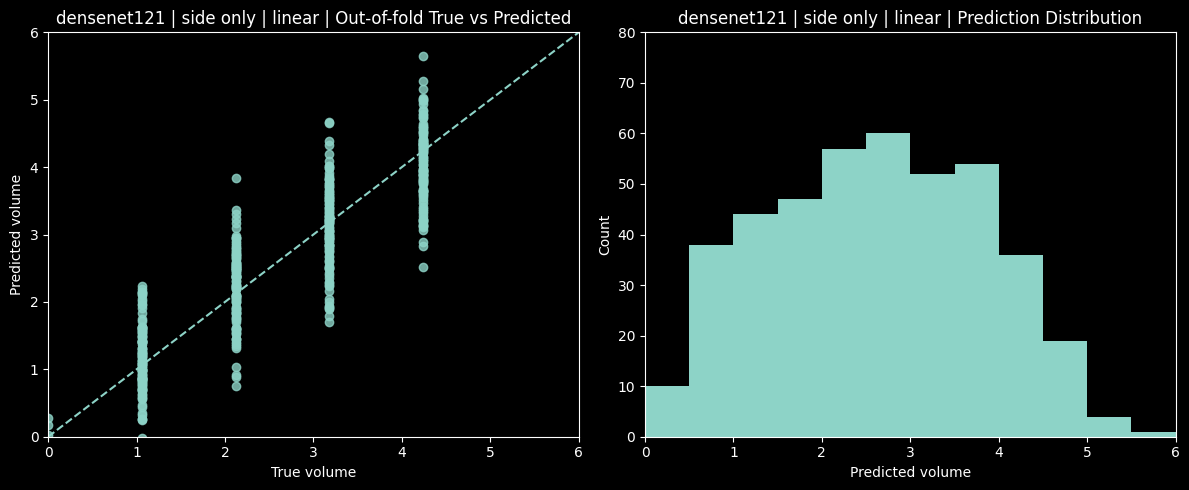

In [7]:
display(results_df)

for _, row in results_df.head(5).iterrows():
    key = (row["backbone"], row["fusion"])
    if key in nested_artifacts:
        artifact = nested_artifacts[key]
        y_true = artifact["y"]
        y_pred = artifact["oof_predictions"][row["regressor"]]
        title = f"{row['backbone']} | {row['fusion']} | {row['regressor']}"
        make_oof_plot(y_true, y_pred, title_prefix=title)


## Save results


In [8]:
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
name = f"only_side_frozen_performance_{timestamp}.csv"
results_df.to_csv(OUTPUT_DIR / name, index=False)
print("Saved:", OUTPUT_DIR / name)

Saved: results/only_side_frozen_performance_2026-04-01_12-55-13.csv
